# Can We Predict Whether a Customer is a High Spender Based on Their Purchasing Patterns?

## Question & Background

### Project Question 
**Can we predict whether a customer is a high spender 
based on their purchasing patterns?** 

### Explanation
We define a high spender as any 
customer whose total amount spent exceeds the average across all customers. 

We use Logistic Regression with three different configurations to answer 
this question and identify which customer behaviors are the strongest 
predictors of high spending.

### Background
Each day, the work of online retailers often leads to the generation of massive amounts of transaction data. Hence, there lies an opportunity to evaluate which customers are high value and could therefore aid businesses that are in need of optimizing retention strategies in order to understand their market and capitalize on it. 

It is our belif that rather than treating all customers the same, businesses can use purchasing behavior to identify their most valuable customers before they actually leave - either cancel their subscription or stop making purcahses.

To do this, this project utilises the UCI Online Retail dataset obtained via GeeksforGeeks and spans a collection of 
541,909 transactions from a UK-based online retailer between 2010 and 2011. 

Each row within the dataset represents one item purchased, including the quantity, price, 
customer ID, and country of purchase.

In [6]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, classification_report
import graphviz  

In [7]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")
df.head(10)
#rn every row is one purchased item so we have to mak eit one row per customer with groupby

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [8]:
#data cleaning
df.describe() #summary of data characteristics so we can see scale of numerics
#quantity and unit price have neg values to show order returns

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
#data types and missing values
print(df.dtypes) # tells us data types so we know if any need to be changed
df.isna().sum() # checks for missing values and tells us how many if any

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Exploratory Data Analysis

Before building any models we first need to understand the data. To do this, we start by 
first analyzing overall revenue trends, customer geographic distribution, 
as well as the distribution of each customer's spendings and order frequency. 


***target variable: how is purchase amount distributed across customers?***

In [10]:
# drop rows with no customer id - so dropping 135080 missing values in customer id 
df = df.dropna(subset=["CustomerID"])

#df.describe showed negative quantities as canceeld in data, canceled orders ahve an invoice # that starts with C
df = df[df['InvoiceNo'].astype(str).str.startswith('C') == False] # only keeps rows where invoice does not start with C

# remove negative and 0 values from quantity and unitprice as per df.describe
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

#gotta change date to datetime so python can use it to do time based calculations
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

# total price - to determine each customer's total purchase amount by multiplying quantity and unit price
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(df.shape)
df.head()

(397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


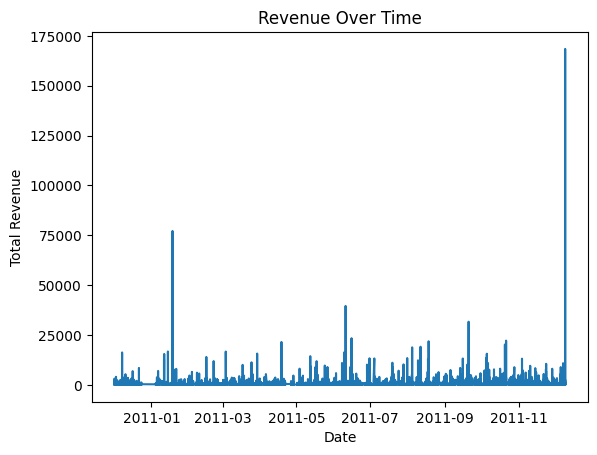

In [11]:
# revenue change over time
revenue = df.groupby('InvoiceDate')['TotalPrice'].sum()
plt.plot(revenue)
plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.show()

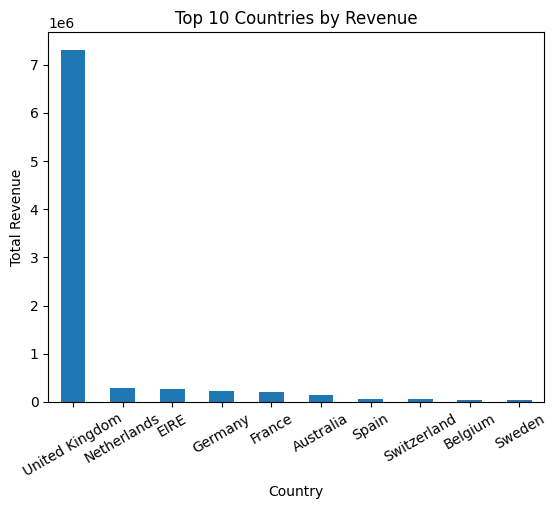

In [12]:
# check for which countries tend to generate the most revenue
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
top_countries = top_countries.head(10)
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

## Findings based on Top Countries Plot: 

Our plot reveals that the UK dominates revenue compared to all other countries within our dataset, therefore making up the vast majority of our customer base. This outcome reveals that cou try would fail to be a meanningful differentiator since utilizing it will lead to our model will primarily predicting spending behavior for UK customers. 

Therefore, it is best that we exclude the "Country" feature and instead focus on creating behavioral features like order frequency and average spend based on our initial features.

In [13]:
# each row in the dataset is for each item purfchased 
# collapse each item row to become customer based features instead of item based features
df_customers = df.groupby('CustomerID').agg(
    TotalSpent    = ('TotalPrice', 'sum'),
    Frequency     = ('InvoiceNo',  'nunique'),
    Avg_OrderValue = ('TotalPrice', 'mean'),
    Avg_Quantity   = ('Quantity',   'mean'),
    Avg_UnitPrice  = ('UnitPrice',  'mean')
).reset_index()

df_customers.head()

,CustomerID,TotalSpent,Frequency,Avg_OrderValue,Avg_Quantity,Avg_UnitPrice
0,12346.0,77183.60,1,77183.600000,74215.000000,1.040000
1,12347.0,4310.00,7,23.681319,13.505495,2.644011
2,12348.0,1797.24,4,57.975484,75.516129,5.764839
3,12349.0,1757.55,1,24.076027,8.643836,8.289041
4,12350.0,334.40,1,19.670588,11.588235,3.841176


In [14]:
# check data types of customer df
print(df_customers.dtypes)

CustomerID        float64
TotalSpent        float64
Frequency           int64
Avg_OrderValue    float64
Avg_Quantity      float64
Avg_UnitPrice     float64
dtype: object


The plot reveals that the UK pred to other nationsking up a large part of the data. So when predicting if an individual is a high spender we'll ideally be dealing with the UK demographic. So instaed of focuing we have to focus on customer spending

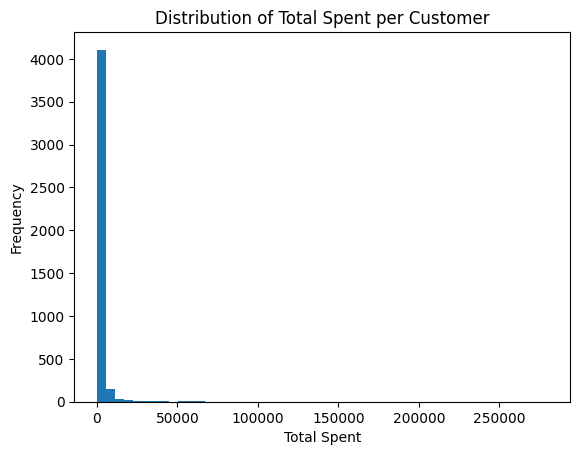

In [15]:
#EDA on new df on customer rows
# how is total spend distributed across customers?
df_customers['TotalSpent'].plot(kind='hist', bins=50)
plt.title('Distribution of Total Spent per Customer')
plt.xlabel('Total Spent')
plt.show()

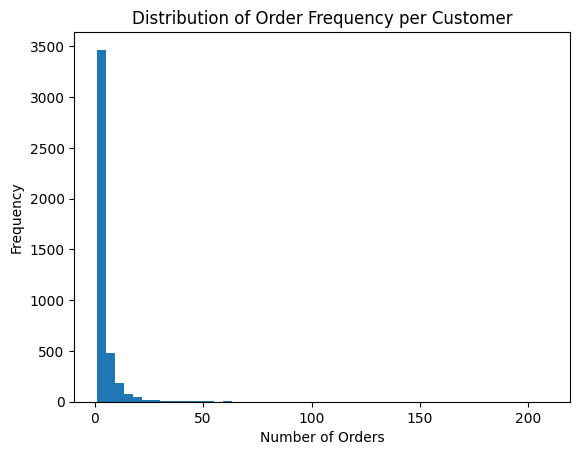

In [16]:
# how many orders do customers typically place?
df_customers['Frequency'].plot(kind='hist', bins=50)
plt.title('Distribution of Order Frequency per Customer')
plt.xlabel('Number of Orders')
plt.show()

In [17]:
#question we're trying to answer: Can we predict whether a customer is a high spender based on their purchasing patterns?
#target variable: high spender (or not)
average_spent = df_customers['TotalSpent'].mean()
df_customers['HighSpender'] = (df_customers['TotalSpent'] > average_spent).astype(int)
print(df_customers['HighSpender'].value_counts())

HighSpender
0    3467
1     871
Name: count, dtype: int64


In [18]:
#prevalence of high spenders in our data
highspender_prev = df_customers['HighSpender'].mean()
print("Prevalence of High Spenders:", highspender_prev)

Prevalence of High Spenders: 0.20078377132319042


In [19]:
# X and y features and target variable
X = df_customers[['Frequency', 'Avg_OrderValue', 'Avg_Quantity', 'Avg_UnitPrice']]
y = df_customers['HighSpender']

In [20]:
# StratifiedKFold for cross validation — same as DT lab
# preserves class ratio in each fold
kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42) #n_repeats repeats the cross validation process 3 times to get more stable estimate of model performance

In [21]:
#pipeline for scaling and modeling
#all feature columns are numeric so we dont need to one hot encode and use column transformer
logis_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logis_model', LogisticRegression(max_iter=1000, random_state=42)) 
])

In [22]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [23]:
from sklearn.metrics import confusion_matrix
# Model 1 — baseline model with lbfgs
logis_pipe_m1 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])


In [24]:
# fit on training data only
logis_pipe_m1.fit(X_train, y_train)

# predict on test set — hard labels and probabilities
y_pred_m1 = logis_pipe_m1.predict(X_test)
y_proba_m1 = logis_pipe_m1.predict_proba(X_test)[:, 1]

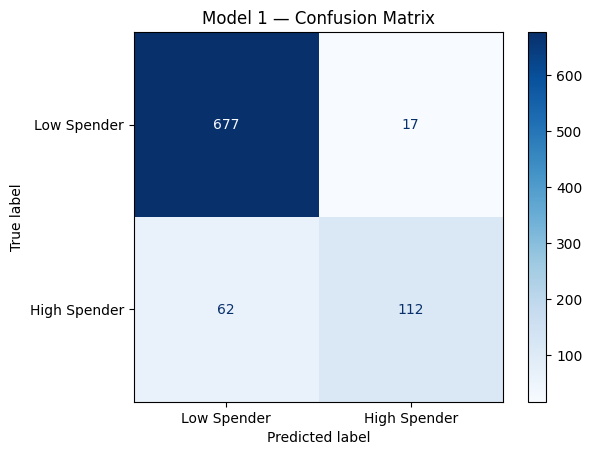

In [25]:
# confusion matrix  model 1 — shows TP, TN, FP, FN
# were using default solver which is lbfgs which shrinks mdoels but not entirely so still has some influence
cm_m1 = confusion_matrix(y_test, y_pred_m1)
ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Low Spender', 'High Spender']).plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.show()

In [26]:
# classification report — shows precision, recall, f1 per class
print(classification_report(y_test, y_pred_m1))

#precision - how accuarte is our model when it predicts a high spender? 
# recall - did our model catch all the high spenders or did it miss some?

              precision    recall  f1-score   support

           0       0.92      0.98      0.94       694
           1       0.87      0.64      0.74       174

    accuracy                           0.91       868
   macro avg       0.89      0.81      0.84       868
weighted avg       0.91      0.91      0.90       868



Model 1 AUC: 0.9386365894862367


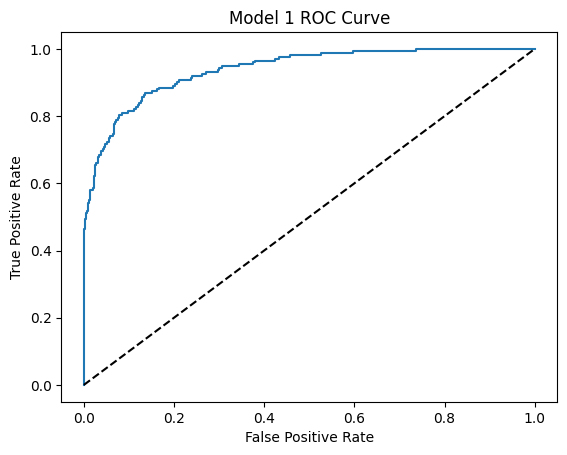

In [27]:
# #ROC curve and AUC for Model 1
from sklearn.metrics import roc_curve

fpr_m1, tpr_m1, _ = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)
print('Model 1 AUC:', auc_m1)
# roc curve — plots TPR vs FPR at different thresholds to show tradeoff between catching more high spenders 
#auc is area under the curve — higher is better, 0.5 is random, 1 is perfect

plt.plot(fpr_m1, tpr_m1)
plt.plot([0,1],[0,1],'k--') # diagonal dashed line for random classifier
plt.title('Model 1 ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [28]:
# Confusion Matrix for Model 2 — saga with L1
# saga does l1 regulization and shrinks coefficients of less important features to 0
from sklearn.metrics import confusion_matrix

#all feature columns are numeric so we dont need to one hot encode and use column transformer
pipe_m2 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='saga', l1_ratio=1, max_iter=1000, random_state=42))
])

In [29]:
# fit on training data only
pipe_m2.fit(X_train, y_train)
# predict on test set — hard labels and probabilities
y_pred_m2 = pipe_m2.predict(X_test)
y_proba_m2 = pipe_m2.predict_proba(X_test)[:, 1]

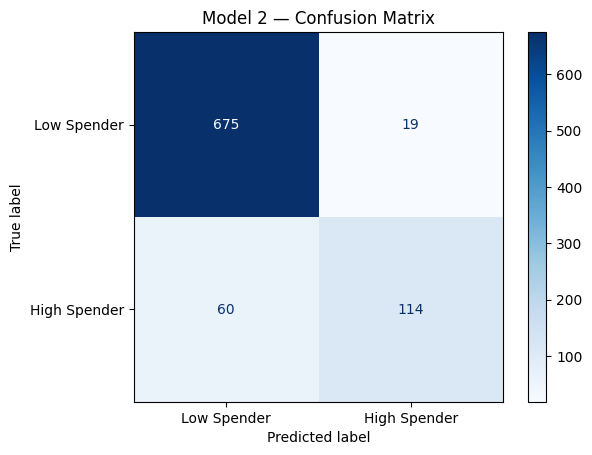

In [30]:
# confusion matrix — shows TP, TN, FP, FN
cm_m2 = confusion_matrix(y_test, y_pred_m2)
ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Low Spender', 'High Spender']).plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.show()

In [31]:
#classification report — shows precision, recall, f1 per class
print(classification_report(y_test, y_pred_m2))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       694
           1       0.86      0.66      0.74       174

    accuracy                           0.91       868
   macro avg       0.89      0.81      0.84       868
weighted avg       0.91      0.91      0.90       868



AUC: 0.9388518996985658


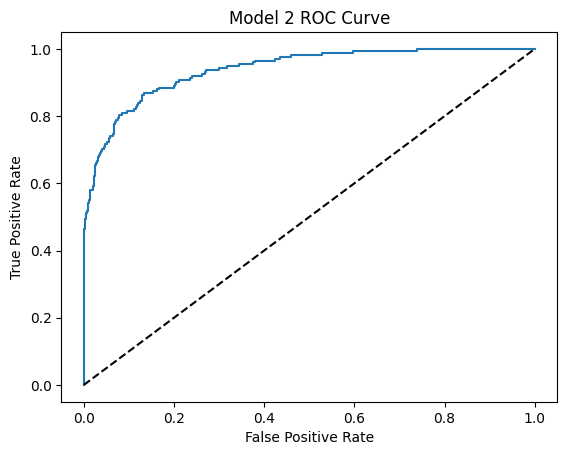

In [32]:
#ROC curve and AUC for Confusion Matrix Model 2
fpr_m2, tpr_m2, _ = roc_curve(y_test, y_proba_m2)
auc_m2 = roc_auc_score(y_test, y_proba_m2)
print('AUC:', auc_m2)

plt.plot(fpr_m2, tpr_m2)
plt.plot([0,1],[0,1],'k--') # diagonal dashed line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 2 ROC Curve')
plt.show()

In [33]:
# Confusion Matrix for Model 3 — class_weight balanced logistic regression
from sklearn.metrics import confusion_matrix    

# class_weight='balanced' puts both classes on equal scale so majority doesnt dominate the model 
pipe_m3 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

In [34]:
# Confusion Matrix for Model 3 — class_weight balanced logistic regression
pipe_m3.fit(X_train, y_train)
y_pred_m3 = pipe_m3.predict(X_test)
y_proba_m3 = pipe_m3.predict_proba(X_test)[:, 1]    

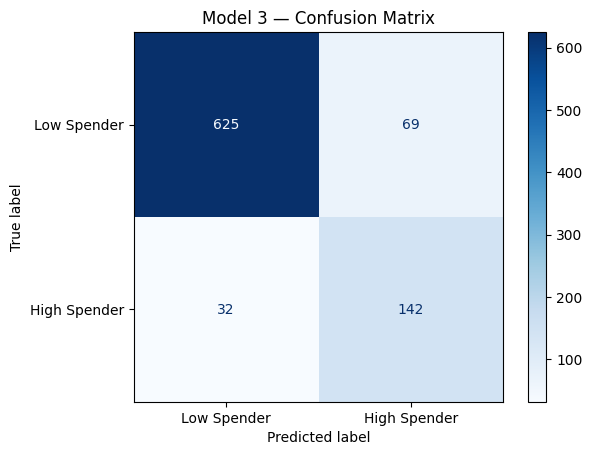

              precision    recall  f1-score   support

           0       0.95      0.90      0.93       694
           1       0.67      0.82      0.74       174

    accuracy                           0.88       868
   macro avg       0.81      0.86      0.83       868
weighted avg       0.90      0.88      0.89       868



In [35]:
# confusion matrix — shows TP, TN, FP, FN
cm_m3 = confusion_matrix(y_test, y_pred_m3)
ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Low Spender', 'High Spender']).plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.show()
#classification report — shows precision, recall, f1 per class
print(classification_report(y_test, y_pred_m3)) 

AUC: 0.9385869025141609


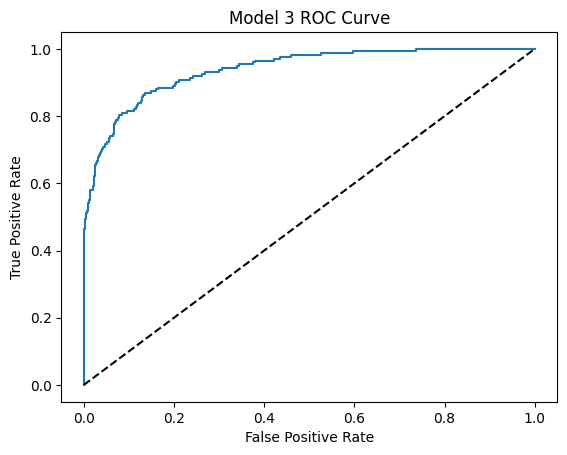

In [36]:
#ROC curve and AUC for Confusion Matrix Model 3
fpr_m3, tpr_m3, _ = roc_curve(y_test, y_proba_m3)
auc_m3 = roc_auc_score(y_test, y_proba_m3)
print('AUC:', auc_m3)

plt.plot(fpr_m3, tpr_m3)
plt.plot([0,1],[0,1],'k--') # diagonal dashed line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 3 ROC Curve')
plt.show()

In [37]:
# compare all 3 models — higher AUC is better
print("Model Comparison")
print("Model 1 AUC:", (roc_auc_score(y_test, y_proba_m1)))
print("Model 2 AUC:", (roc_auc_score(y_test, y_proba_m2)))
print("Model 3 AUC:", (roc_auc_score(y_test, y_proba_m3)))

Model Comparison
Model 1 AUC: 0.9386365894862367
Model 2 AUC: 0.9388518996985658
Model 3 AUC: 0.9385869025141609


# MODEL #2

Decision Tree AUC: 0.920724436052867


              precision    recall  f1-score   support

           0       0.91      0.98      0.94       694
           1       0.88      0.60      0.72       174

    accuracy                           0.90       868
   macro avg       0.90      0.79      0.83       868
weighted avg       0.90      0.90      0.90       868



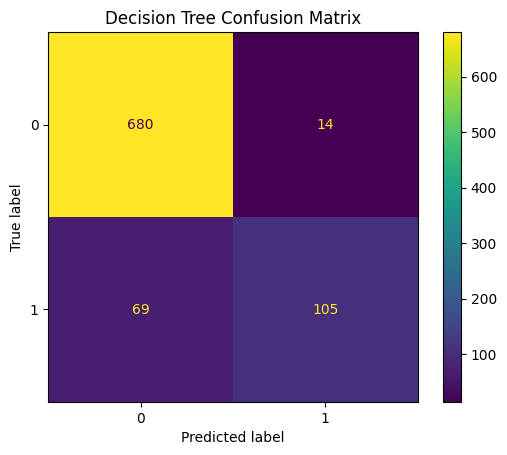

In [38]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay


# build model
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)


# train
dt_model.fit(X_train, y_train)


# predict
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:,1]


# evaluate
print("Decision Tree AUC:", roc_auc_score(y_test, y_proba_dt))
print(classification_report(y_test, y_pred_dt))


ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test)
plt.title("Decision Tree Confusion Matrix")
plt.show()

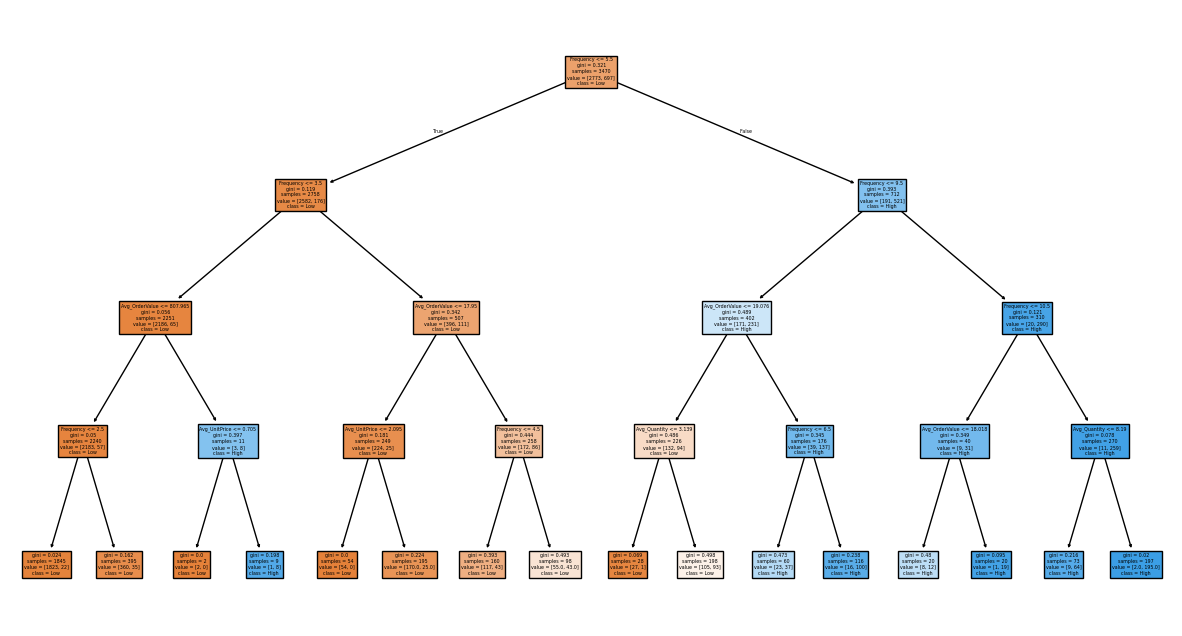

In [40]:
from sklearn.tree import plot_tree


plt.figure(figsize=(15,8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Low", "High"],
    filled=True
)
plt.show()


Random Forest AUC: 0.9453857365265494
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       694
           1       0.86      0.66      0.74       174

    accuracy                           0.91       868
   macro avg       0.89      0.81      0.84       868
weighted avg       0.91      0.91      0.90       868



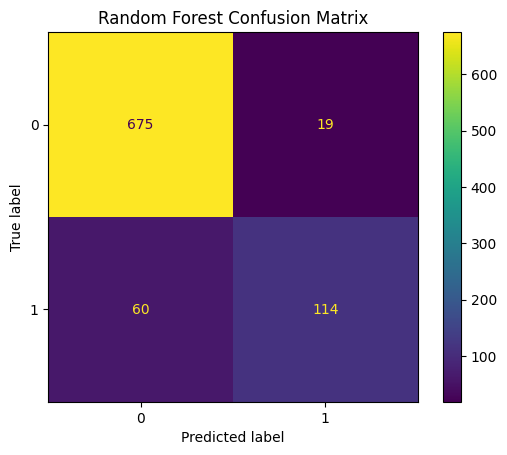

In [41]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)


# train
rf_model.fit(X_train, y_train)


# predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]


# evaluate
print("Random Forest AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))


ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

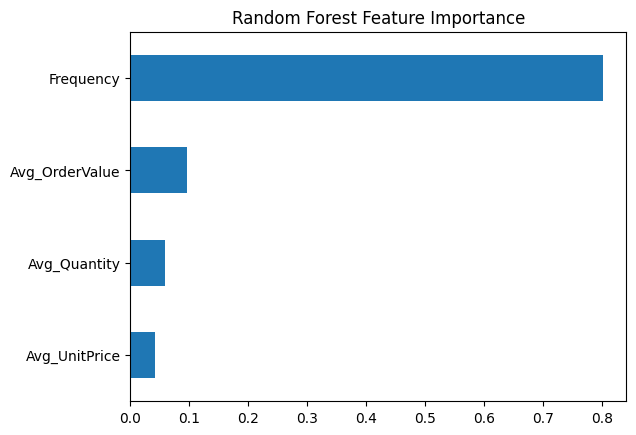

In [42]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()